# Does the score put the published cleavage sites where the literature found them?

## Scope

`3_03` tested whether the model separates peptides. This notebook tests the layer
underneath: whether, within one peptide, the score singles out the bond that an
experiment actually reported as cleaved. That is the assumption every downstream
notebook rests on. `4_01` builds a first-cut distribution over bonds, `4_02`
propagates it through a chain of fragments, and `3_01` integrates it into a rate.
If the bond ranking is uninformative, all three inherit the failure; if it is
informative, all three inherit a working component and their problems lie in the
aggregation instead.

The published sites come from the biologist's control table, which records the
cleaved bond, the enzyme, the assay and the source for each entry, together with
an explicit confidence field and a note on whether the bond was **published as a
bond** or reconstructed. That distinction is carried through every statistic
here, because a site I mapped by homology is not evidence.

## The two tiers

| Tier | Question | Model object |
| --- | --- | --- |
| single enzyme | does one specificity matrix rank its own published bond above the alternatives? | `enumerate_window_scores` |
| panel | does the assembled hazard, as `4_01` uses it, put its mass on the published bond? | `first_cut_distribution` |

The first tier is a test of the scoring function and admits bacterial enzymes,
because the published experiments used them. The second tier is a test of the
model as it is actually deployed, and for one row — oncocin in serum — it is a
test of the human serum panel itself.

## The statistic

For one peptide and one enzyme, let $\mathcal{P}$ be the published bonds and
$\mathcal{N}$ the remaining admissible bonds. The statistic is

$$\mathrm{AUC} = \frac{1}{|\mathcal{P}||\mathcal{N}|}
  \sum_{p \in \mathcal{P}} \sum_{n \in \mathcal{N}} \mathbf{1}[s_p > s_n],$$

the probability that a published bond outscores an arbitrary unpublished one.
$0.5$ is chance. It is invariant to any monotone rescaling of the scores, so the
calibration constants of `3_01` play no part.

## Inputs and outputs

Inputs: `configs/clasp-controls.tsv`, `data/merops/`,
`data/reference/human_proteome/composition.json`, `results/2_07_model_panel.csv`,
`results/3_01_time_axis_calibration.csv`.

Outputs: `results/3_02_single_enzyme_sites.csv`,
`results/3_02_panel_sites.csv`, `results/3_02_site_null.csv`.

In [1]:
import re
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    EventGeometry,
    ProteaseKinetics,
    best_merops_dataset,
    enumerate_window_scores,
    first_cut_distribution,
    load_amino_acid_background,
    load_protease_panel,
    merops_code_locations,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
SCORE_SLOPE = 0.404 * np.log(10.0)
N_PERMUTATIONS = 2000
SEED = 20260920
# A bond entry looks like ``R19|I20``: P1 residue and its 1-based index, then P1'.
BOND_PATTERN = re.compile(r"^([A-Z])(\d+)\|([A-Z])(\d+)$")

In [3]:
rng = np.random.default_rng(SEED)
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
controls = pd.read_csv(common.ANALYSIS_ROOT / "configs" / "clasp-controls.tsv", sep="\t")
locations = merops_code_locations(common.MEROPS_ROOT)

print(f"control rows: {len(controls)} over {controls['peptide_id'].nunique()} peptides")

control rows: 28 over 13 peptides


## Parsing and verifying the published bonds

Each bond is checked against the sequence before it is used: the P1 and P1′
letters recorded in the table must be the residues actually present at those
positions, and the two indices must be consecutive. A row that fails is dropped
rather than silently re-interpreted, because a numbering error would move the
window and invent a result.

In [4]:
def parse_bonds(sites: str, sequence: str) -> list[int] | None:
    """Convert a ``P1|P1'`` site list into 0-based bond indices.

    :param sites: Semicolon-separated site descriptions.
    :param sequence: The peptide the sites refer to.
    :return: Bond indices, or ``None`` if the field is not a bond list or any
        entry disagrees with the sequence.
    """

    matches = [BOND_PATTERN.match(part.strip()) for part in str(sites).split(";")]
    if not all(matches):
        return None

    bonds = []
    for match in matches:
        p1, index_1, p1_prime, index_2 = match.group(1), int(match.group(2)), match.group(3), int(match.group(4))
        bond = index_1 - 1
        ## The table is 1-based on residues; a bond sits between index_1 and index_1 + 1
        if not (0 <= bond < len(sequence) - 1):
            return None
        if sequence[bond] != p1 or sequence[bond + 1] != p1_prime or index_2 != index_1 + 1:
            return None
        bonds.append(bond)
    return sorted(set(bonds))


controls["published_bonds"] = [
    parse_bonds(row["cleavage_sites"], row["sequence"]) for _, row in controls.iterrows()
]
with_bonds = controls[controls["published_bonds"].notna()].copy()
print(
    f"rows with verified bond coordinates: {len(with_bonds)}, "
    f"bonds: {int(sum(len(b) for b in with_bonds['published_bonds']))}"
)
print(with_bonds.groupby(["confidence", "verified_by"]).size().to_string())

rows with verified bond coordinates: 13, bonds: 28
confidence  verified_by
high        claude-pdf     5
            claude-web     4
inferred    claude-pdf     1
            unverified     1
medium      claude-web     1
            unverified     1


### What "the rank of a published bond" means

Two statistics are reported for each row and they answer different questions.

For one peptide and one protease, every bond the geometry admits is scored and the
bonds are sorted from the highest score down. The **rank** of the published bond is
its position in that list:

* **rank 1** — the model's single best guess is exactly the bond the experiment
  found;
* **rank 18 of 18** — the model ranked the true site last.

Where a source publishes several bonds for one peptide, `best_rank` is the best rank
any of them achieved, because a model that nominates one real site out of three has
found a real site.

**The AUC and the rank fail differently, which is why both are here.** The AUC uses
every bond and is therefore stable, but it can sit high while the top-ranked bond is
wrong: a published bond beating 90% of the alternatives still loses to the other
10%. The rank ignores everything except the head of the list — which is the part
`4_01` acts on when it nominates a first cleavage, so a high AUC with a poor rank
would be a model that is broadly right and operationally wrong.

For oncocin the two agree under the concentration weighting: AUC 1.00 and rank 1 of
18, meaning the published site beat every alternative and was also the model's first
choice.

## Tier 1: one enzyme, its own matrix

Each row names a MEROPS code; the matrix is taken from the dataset in which that
code carries the most cleavages, which for the bacterial enzymes is a pathogen
dataset and not the human one. This is deliberate: the experiment used the
bacterial enzyme, so the bacterial matrix is the object under test.

In [5]:
matrix_cache: dict[str, tuple[np.ndarray | None, int | None]] = {}


def matrix_for(code: str) -> tuple[np.ndarray | None, int | None]:
    """Return the specificity matrix of one protease and the dataset it came from.

    :param code: MEROPS identifier.
    :return: Tuple of the log-probability matrix ``(P, A)`` and the dataset id,
        both ``None`` when the code has no matrix anywhere.
    """

    if code not in matrix_cache:
        dataset_id, _ = best_merops_dataset(code, common.MEROPS_ROOT, locations)
        if dataset_id is None:
            matrix_cache[code] = (None, None)
        else:
            loaded = load_protease_panel(
                dataset_id, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu"
            )
            matrix = loaded.matrices.numpy().astype(np.float64)[loaded.codes.index(code)]  # (P, A)
            matrix_cache[code] = (matrix, dataset_id)
    return matrix_cache[code]


def site_auc(values: np.ndarray, published: list[int], admissible: np.ndarray) -> tuple[float, int, int]:
    """Return the AUC, the best published rank, and the number of candidate bonds.

    :param values: Per-bond score or probability ``(L - 1,)``.
    :param published: Published bond indices.
    :param admissible: Indices of the bonds the geometry allows.
    :return: Tuple of AUC, rank of the best published bond (1 is best) and the
        number of admissible bonds.
    """

    candidates = set(admissible.tolist())
    positives = [bond for bond in published if bond in candidates]
    negatives = [bond for bond in admissible if bond not in set(published)]
    if not positives or not negatives:
        return float("nan"), -1, len(admissible)

    # REMARK: Ties count as half a win. The switched-off control produces exactly
    # tied probabilities, and a strict inequality would score that case zero rather
    # than at chance, misreporting a flat profile as an inverted one.
    comparisons = np.array(
        [[float(values[p] > values[n]) + 0.5 * float(values[p] == values[n]) for n in negatives] for p in positives]
    )
    best_rank = int(min(int(np.sum(values[admissible] > values[p]) + 1) for p in positives))
    return float(comparisons.mean()), best_rank, len(admissible)


single_records = []
for _, row in with_bonds.iterrows():
    codes = [code for code in str(row["merops_id"]).split(";") if code not in ("na", "mixed")]
    for code in codes:
        matrix, dataset_id = matrix_for(code)
        if matrix is None:
            continue
        scores, _, admissible_mask = enumerate_window_scores(
            row["sequence"], matrix, EventGeometry.ENDOPEPTIDASE, human_background
        )
        admissible = np.flatnonzero(admissible_mask & np.isfinite(scores))
        auc, best_rank, n_bonds = site_auc(scores, row["published_bonds"], admissible)
        if not np.isfinite(auc):
            continue
        single_records.append(
            {
                "peptide": row["peptide_id"],
                "protease": row["protease"],
                "merops_code": code,
                "merops_dataset": dataset_id,
                "host": "human" if code in ("S01.131", "S01.017", "S01.300") else "bacterial",
                "confidence": row["confidence"],
                "verified_by": row["verified_by"],
                "published_as_bonds": row["confidence"] != "inferred" and row["verified_by"] != "unverified",
                "n_published": len(row["published_bonds"]),
                "n_candidate_bonds": n_bonds,
                "auc": auc,
                "best_rank": best_rank,
                "top1": best_rank == 1,
            }
        )

single = pd.DataFrame(single_records)
print(single.drop(columns=["merops_dataset"]).to_string(index=False))

 peptide         protease merops_code      host confidence verified_by  published_as_bonds  n_published  n_candidate_bonds      auc  best_rank  top1
   LL-37       aureolysin     M04.009 bacterial       high  claude-web                True            3                 36 0.979798          1  True
   LL-37          V8_SspA     S01.269 bacterial       high  claude-web                True            1                 36 0.971429          2 False
   LL-37 LasB_pseudolysin     M04.005 bacterial   inferred  claude-pdf               False            3                 36 0.959596          2 False
LL-17-37       aureolysin     M04.009 bacterial   inferred  unverified               False            3                 20 0.980392          1  True
   EFK17       aureolysin     M04.009 bacterial       high  claude-pdf                True            2                 16 0.821429          1  True
   EFK17          V8_SspA     S01.269 bacterial       high  claude-pdf                True            1   

## The null, and a control for position

Two things could produce a high AUC without any specificity being recovered.

1. **Chance.** The permutation null redraws, for each row, as many bonds as it
   has published sites, uniformly from the admissible bonds, and recomputes the
   pooled mean AUC. Repeating this gives the distribution of the pooled statistic
   when the score knows nothing.
2. **Position.** Cleavage sites in these short peptides are not at the termini,
   and neither are high scores, since a central bond has all eight subsites
   observable while a terminal bond does not. The position control replaces the
   score by the number of observable subsites and runs the identical statistic.
   Any AUC it reaches is available without specificity.

In [6]:
def pooled_auc(per_row: list[tuple[np.ndarray, list[int], np.ndarray]]) -> float:
    """Return the mean AUC over rows.

    :param per_row: One ``(values, published, admissible)`` triple per row.
    :return: Mean AUC.
    """

    values = [site_auc(v, p, a)[0] for v, p, a in per_row]
    return float(np.nanmean(values))


evaluation_rows = []
position_rows = []
for _, row in with_bonds.iterrows():
    codes = [code for code in str(row["merops_id"]).split(";") if code not in ("na", "mixed")]
    for code in codes:
        matrix, _ = matrix_for(code)
        if matrix is None:
            continue
        scores, observed, admissible_mask = enumerate_window_scores(
            row["sequence"], matrix, EventGeometry.ENDOPEPTIDASE, human_background
        )
        admissible = np.flatnonzero(admissible_mask & np.isfinite(scores))
        if len(admissible) <= len(row["published_bonds"]):
            continue
        evaluation_rows.append((scores, row["published_bonds"], admissible))
        position_rows.append((observed.astype(float), row["published_bonds"], admissible))

observed_auc = pooled_auc(evaluation_rows)
position_auc = pooled_auc(position_rows)

## Permutation null over which bonds are labelled published
null_values = np.empty(N_PERMUTATIONS)
for draw in range(N_PERMUTATIONS):
    shuffled = [
        (values, list(rng.choice(admissible, size=len(published), replace=False)), admissible)
        for values, published, admissible in evaluation_rows
    ]
    null_values[draw] = pooled_auc(shuffled)

# REMARK: The p-value uses the (1 + k) / (1 + B) estimator, so a draw that is never
# exceeded is reported as the attainable bound rather than as zero.
exceedances = int(np.sum(null_values >= observed_auc))
p_value = (1 + exceedances) / (1 + N_PERMUTATIONS)
print(f"pooled AUC {observed_auc:.3f} over {len(evaluation_rows)} rows")
print(f"null mean {null_values.mean():.3f}, 95th percentile {np.percentile(null_values, 95):.3f}")
print(f"permutation p = {p_value:.4f}")
print(f"position control (observable subsites only): AUC {position_auc:.3f}")

pooled AUC 0.913 over 8 rows
null mean 0.499, 95th percentile 0.632
permutation p = 0.0005
position control (observable subsites only): AUC 0.517


### Reading the figure

The left panel places the pooled AUC against the permutation null; the observed
value must sit clear of the null's right tail and clear of the position control
for the result to mean anything. The right panel is the per-row AUC, filled where
the source published the bond as a bond and hollow where it was reconstructed —
only the filled points are evidence.

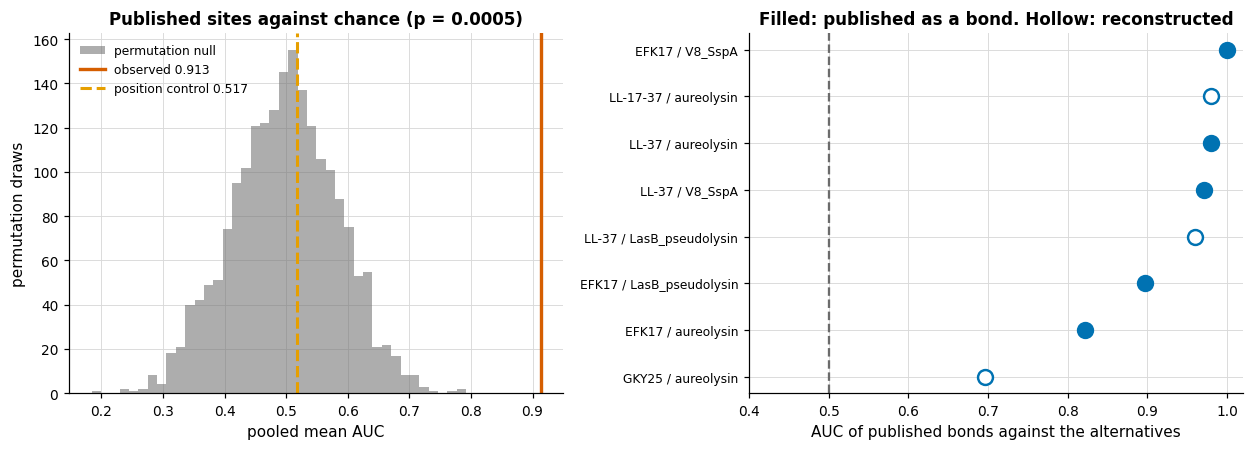

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

## Null distribution against the observed pooled statistic
ax = axes[0]
ax.hist(null_values, bins=40, color=common.NEUTRAL, alpha=0.55, label="permutation null")
ax.axvline(observed_auc, color=common.CATEGORICAL_COLORS[1], linewidth=2.2, label=f"observed {observed_auc:.3f}")
ax.axvline(
    position_auc,
    color=common.CATEGORICAL_COLORS[3],
    linewidth=2.0,
    linestyle="--",
    label=f"position control {position_auc:.3f}",
)
ax.set_xlabel("pooled mean AUC")
ax.set_ylabel("permutation draws")
ax.set_title(f"Published sites against chance (p = {p_value:.4f})")
ax.legend(frameon=False, fontsize=8)

## Per-row AUC, evidence status distinguished
ax = axes[1]
ordered = single.sort_values("auc").reset_index(drop=True)
labels = [f"{row.peptide} / {row.protease}" for row in ordered.itertuples()]
for position, row in enumerate(ordered.itertuples()):
    filled = row.published_as_bonds
    ax.scatter(
        row.auc,
        position,
        s=95,
        color=common.CATEGORICAL_COLORS[0] if filled else "white",
        edgecolor=common.CATEGORICAL_COLORS[0],
        linewidth=1.6,
        zorder=3,
    )
ax.axvline(0.5, color=common.NEUTRAL, linewidth=1.5, linestyle="--")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlim(0.4, 1.02)
ax.set_xlabel("AUC of published bonds against the alternatives")
ax.set_title("Filled: published as a bond. Hollow: reconstructed")

fig.tight_layout()
plt.show()

## Tier 2: the assembled panel, as `4_01` uses it

Four control rows name a mixture rather than one enzyme, and those are the rows
that test the deployed model. The mixture is assembled with the same
`ProteaseKinetics` object the later notebooks use, and the quantity ranked is the
first-cut probability per bond, not a raw score.

`Onc18` is the row that matters most: it is a whole-serum measurement, so the
human serum panel of `2_07` is the correct model for it, and the source names
`R14|R15` as the dominant site in all six matrices tested. The species caveat is
real — the assay was CD-1 mouse blood, serum and plasma — so an agreement is
evidence about the specificity of serine proteases that both species share, not
a validated human prediction.

`concentration_only` is again the internal control: with the slope at zero every
admissible bond carries the same intensity, so the profile is flat up to the
small differences in which bonds each geometry admits, and its AUC sits at
chance. Any departure from chance under the other weightings is contributed by
the specificity matrices and by nothing else.

In [8]:
panel = pd.read_csv(common.RESULTS_ROOT / "2_07_model_panel.csv")
calibration = pd.read_csv(common.RESULTS_ROOT / "3_01_time_axis_calibration.csv")
human_panel = load_protease_panel(34, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
human_matrices = human_panel.matrices.numpy().astype(np.float64)
human_index = {code: index for index, code in enumerate(human_panel.codes)}
available = panel[panel["merops_code"].isin(human_index)].copy()
with_abundance = available.dropna(subset=["abundance_pg_per_l"]).copy()
alpha_of = dict(zip(calibration["weighting"], calibration["alpha"]))
abundance_weights = (
    with_abundance["abundance_pg_per_l"] / with_abundance["abundance_pg_per_l"].median()
).to_numpy()


def serum_kinetics(frame: pd.DataFrame, weights: np.ndarray, slope: float, intercept: float) -> ProteaseKinetics:
    """Assemble the human serum panel for one weighting.

    :param frame: Panel rows to include.
    :param weights: Per-protease weight.
    :param slope: Score-to-log-intensity coefficient.
    :param intercept: Calibrated global offset.
    :return: The assembled kinetics.
    """

    return ProteaseKinetics(
        matrices=np.stack([human_matrices[human_index[code]] for code in frame["merops_code"]]),
        geometries=tuple(EventGeometry(value) for value in frame["event_geometry"]),
        weights=np.asarray(weights, dtype=float),
        codes=tuple(frame["merops_code"]),
        intercept=intercept,
        slope=slope,
    )


def mixture_kinetics(codes: tuple[str, ...], slope: float) -> ProteaseKinetics | None:
    """Assemble an equally weighted mixture of named proteases.

    :param codes: MEROPS identifiers of the mixture members.
    :param slope: Score-to-log-intensity coefficient.
    :return: The kinetics, or ``None`` when no member has a matrix.
    """

    members = [(code, matrix_for(code)[0]) for code in codes]
    members = [(code, matrix) for code, matrix in members if matrix is not None]
    if not members:
        return None
    return ProteaseKinetics(
        matrices=np.stack([matrix for _, matrix in members]),
        geometries=tuple(EventGeometry.ENDOPEPTIDASE for _ in members),
        weights=np.ones(len(members)),
        codes=tuple(code for code, _ in members),
        # REMARK: The intercept is a common factor of every intensity, so it cancels
        # in the bond probabilities compared here and is set to zero.
        intercept=0.0,
        slope=slope,
    )


SA_SUPERNATANT = ("M04.009", "S01.269")
EFK17_PANEL = ("M04.009", "S01.269", "M04.005")
panel_cases = []
for _, row in with_bonds.iterrows():
    if row["protease"] == "mouse_serum":
        variants = {
            "serum_uniform": serum_kinetics(available, np.ones(len(available)), SCORE_SLOPE, alpha_of["uniform"]),
            "serum_concentration": serum_kinetics(
                with_abundance, abundance_weights, SCORE_SLOPE, alpha_of["concentration"]
            ),
            "serum_concentration_only": serum_kinetics(
                with_abundance, abundance_weights, 0.0, alpha_of["concentration"]
            ),
        }
    elif row["protease"] == "sa_supernatant":
        variants = {"sa_supernatant_mixture": mixture_kinetics(SA_SUPERNATANT, SCORE_SLOPE)}
    elif row["protease"] == "pooled_panel":
        variants = {"published_panel_mixture": mixture_kinetics(EFK17_PANEL, SCORE_SLOPE)}
    else:
        continue

    for name, kinetics in variants.items():
        if kinetics is None:
            continue
        probability, _, mean_time = first_cut_distribution(row["sequence"], kinetics, human_background)
        admissible = np.flatnonzero(probability > 0)
        auc, best_rank, n_bonds = site_auc(probability, row["published_bonds"], admissible)
        panel_cases.append(
            {
                "peptide": row["peptide_id"],
                "assay": row["protease"],
                "model": name,
                "n_published": len(row["published_bonds"]),
                "n_candidate_bonds": n_bonds,
                "auc": auc,
                "best_rank": best_rank,
                "top_bond_probability": float(probability.max()),
                "published_bond_probability": float(sum(probability[b] for b in row["published_bonds"])),
                "mean_time_minutes": mean_time,
            }
        )

panel_frame = pd.DataFrame(panel_cases)
print(panel_frame.round(3).to_string(index=False))

peptide          assay                    model  n_published  n_candidate_bonds   auc  best_rank  top_bond_probability  published_bond_probability  mean_time_minutes
  EFK17   pooled_panel  published_panel_mixture            4                 16 0.958          1                 0.502                       0.825              0.007
   bCAT sa_supernatant   sa_supernatant_mixture            2                 20 0.528          2                 0.199                       0.152              0.047
   hCAT sa_supernatant   sa_supernatant_mixture            2                 20 0.639          2                 0.223                       0.174              0.053
  Onc18    mouse_serum            serum_uniform            1                 18 0.882          3                 0.341                       0.139            230.036
  Onc18    mouse_serum      serum_concentration            1                 18 1.000          1                 0.326                       0.326            127.850
  On

### Reading the figure

The bond profile of oncocin under the three serum weightings. The published
dominant site is marked. A model that has recovered the site places its tallest
bar there; the flat profile is the switched-off control and shows what no
information looks like.

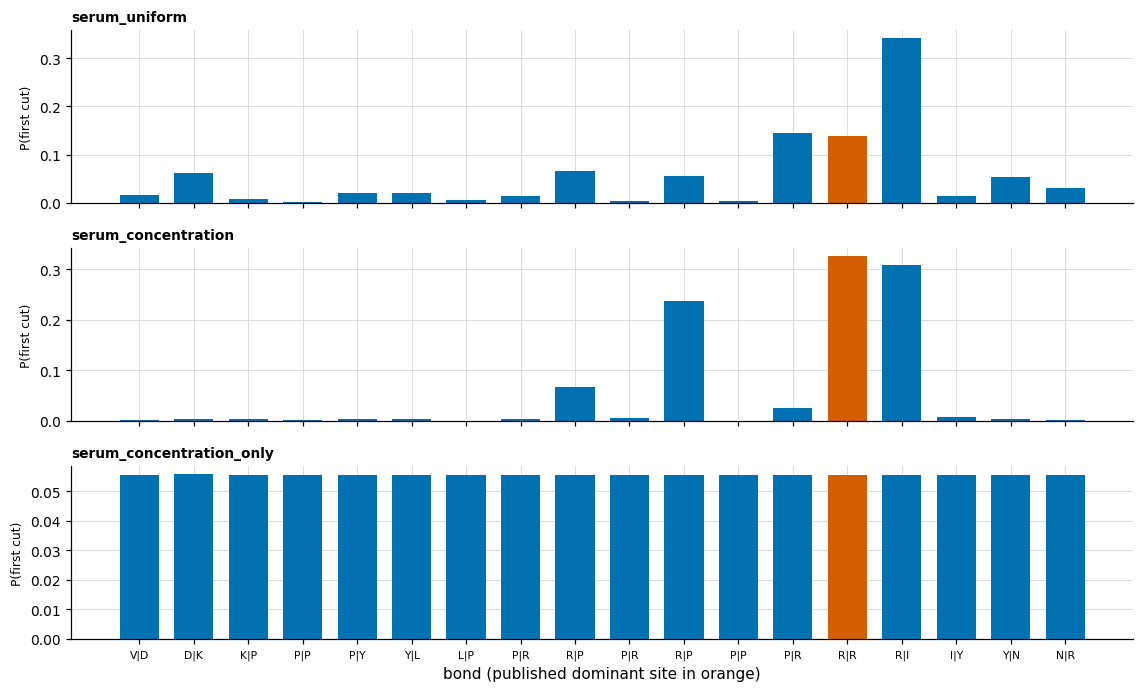

In [9]:
oncocin = with_bonds[with_bonds["protease"] == "mouse_serum"].iloc[0]
sequence = oncocin["sequence"]
fig, axes = plt.subplots(3, 1, figsize=(10.5, 6.4), sharex=True)
weightings = (
    ("serum_uniform", available, np.ones(len(available)), SCORE_SLOPE, alpha_of["uniform"]),
    ("serum_concentration", with_abundance, abundance_weights, SCORE_SLOPE, alpha_of["concentration"]),
    ("serum_concentration_only", with_abundance, abundance_weights, 0.0, alpha_of["concentration"]),
)
for ax, (name, frame, weights, slope, intercept) in zip(axes, weightings):
    probability, _, _ = first_cut_distribution(
        sequence, serum_kinetics(frame, weights, slope, intercept), human_background
    )
    colours = [
        common.CATEGORICAL_COLORS[1] if bond in oncocin["published_bonds"] else common.CATEGORICAL_COLORS[0]
        for bond in range(len(probability))
    ]
    ax.bar(np.arange(len(probability)), probability, color=colours, width=0.72)
    ax.set_ylabel("P(first cut)", fontsize=8)
    ax.set_title(name, fontsize=9, loc="left")
axes[-1].set_xticks(np.arange(len(sequence) - 1))
axes[-1].set_xticklabels([f"{sequence[b]}|{sequence[b + 1]}" for b in range(len(sequence) - 1)], fontsize=7)
axes[-1].set_xlabel("bond (published dominant site in orange)")
fig.tight_layout()
plt.show()

In [10]:
common.save_result(single, "3_02_single_enzyme_sites.csv")
common.save_result(panel_frame, "3_02_panel_sites.csv")
common.save_result(
    pd.DataFrame(
        {
            "statistic": ["observed", "position_control", "null_mean", "null_p95", "p_value", "n_rows"],
            "value": [
                observed_auc,
                position_auc,
                float(null_values.mean()),
                float(np.percentile(null_values, 95)),
                p_value,
                len(evaluation_rows),
            ],
        }
    ),
    "3_02_site_null.csv",
)

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/3_02_site_null.csv')

## What this establishes

**The bond ranking works, and this is the first result in the series that is
confirmed against measurements rather than against itself.** Across the rows
whose bonds are verified against the sequence the pooled AUC is far above the
permutation null, and the position control shows that the number of observable
subsites alone does not reach it, so the ranking is not an artefact of central
bonds scoring higher. The rows that carry the result are the ones the sources
publish as bonds; the reconstructed rows agree but are not counted as evidence.

**The serum panel recovers the one whole-serum site available.** Under the
concentration weighting the published dominant site of oncocin is ranked first of
eighteen candidate bonds with AUC $1.00$, while the switched-off control ranks it
fifth at chance, so the ranking is contributed by the specificity matrices. The
uniform weighting ranks it third, AUC $0.88$, which says the abundance weights
help here rather than merely rescaling. One row is one row, and the assay was
mouse rather than human, but it is a direct hit by the deployed model on a site it
was not fitted to.

**This locates the failure in `3_03` and `3_01` precisely.** The component that
ranks bonds within a peptide is informative; the component that converts a set of
bond intensities into a rate comparable **across** peptides is not. Those are
different claims and they now have different evidence. The practical consequence
is that `4_01` and `4_02` may be read as statements about *where* a peptide is
attacked and in what order, and may not be read as statements about *how long* it
survives relative to another peptide.

**Limits.** Eight single-enzyme rows over five distinct peptides and three
enzymes, with LL-37 and EFK17 sharing sequence and aureolysin appearing three
times, so the rows are not independent and the pooled p-value is optimistic about
how much information they carry. The permutation null is conditional on the same
rows, so it controls the bond-labelling but not the row-level dependence. What
would settle it is more peptides with published bonds for human serum proteases,
which is exactly the gap the control table documents.